# Clustering time-series windows by shape — `method="gmm-toeplitz"`

Some data is an **ordered, stationary signal**: a fixed-length time-series window, a trajectory, a
sensor / audio / vibration waveform, the lag features of one process. There the clustering signal
lives in **how neighbouring positions co-vary**, not in the raw coordinate values. Two AR processes
can have the *identical* per-coordinate distribution and differ only in their autocovariance — and
then:

- a **diagonal** GMM sees only per-coordinate variances → it is **blind**;
- a **full**-covariance GMM needs `N_k > d` points per component to estimate a dense `d × d` matrix →
  it is **singular** in the common "few windows, long window" regime;
- **`method="gmm-toeplitz"`** models each component covariance as an **AR(w)** process (a banded,
  positive-definite Toeplitz precision via Levinson-Durbin, `O(w)` parameters) — well-posed at
  `N_k ≪ d`, and it *improves* as the window grows.

All numbers are computed live. See [`docs/adr/001-gmm-toeplitz.md`](../docs/adr/001-gmm-toeplitz.md).

In [1]:
import betula_cluster
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import adjusted_rand_score as ari
from sklearn.mixture import GaussianMixture

sns.set_theme(style="whitegrid", context="notebook", palette="deep")

print("betula-cluster", betula_cluster.__version__)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

SPECS = ([0.8], [1.1, -0.4], [])  # AR(1) a=0.8 · AR(2) [1.1,-0.4] · white-noise control
NAMES = ["AR(1)  a=0.8", "AR(2)  [1.1, -0.4]", "white noise"]


def ar_windows(n, d, a, rng):
    """`n` length-`d` windows from a zero-mean AR(len(a)) process, rescaled to unit variance."""
    a = np.asarray(a, float)
    w = len(a)
    out = np.empty((n, d))
    for k in range(n):
        buf = np.zeros(d + 256)
        e = rng.normal(size=d + 256)
        for t in range(w, d + 256):
            buf[t] = (a * buf[t - w : t][::-1]).sum() + e[t] if w else e[t]
        win = buf[256:]
        out[k] = (win - win.mean()) / win.std()
    return out


def make_mixture(d, per, seed):
    rng = np.random.default_rng(seed)
    xs = [ar_windows(per, d, a, rng) for a in SPECS]
    y = np.concatenate([np.full(per, c) for c in range(len(SPECS))])
    return np.ascontiguousarray(np.vstack(xs), dtype=np.float64), y

betula-cluster 0.7.0


## The data — three processes that look alike

A few windows from each component (length 128). To the eye they are the same standardized noise —
and their per-coordinate statistics **are** the same. The difference is only in the autocorrelation:
AR(1) is smooth and persistent, AR(2) oscillates, white noise is uncorrelated.

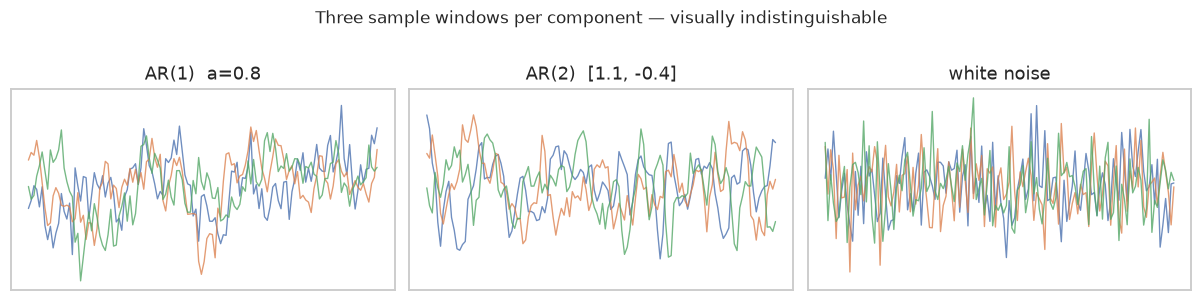

In [2]:
d = 128
X, y = make_mixture(d, per=30, seed=1)

fig, axes = plt.subplots(1, 3, figsize=(11, 2.6), sharey=True)
for c, (ax, name) in enumerate(zip(axes, NAMES)):
    for row in X[y == c][:3]:
        ax.plot(row, lw=0.9, alpha=0.8)
    ax.set(title=name, xticks=[], yticks=[])
fig.suptitle("Three sample windows per component — visually indistinguishable", y=1.03)
fig.tight_layout()
plt.show()

## The real discriminator — the autocovariance

Pool the lagged products `E[x_t · x_{t+τ}]` within each component. *This* is where the components
separate: the AR(1) autocovariance decays slowly, the AR(2) one oscillates, white noise drops to
zero at lag 1. `gmm-toeplitz` fits exactly this curve (as an AR model) per component.

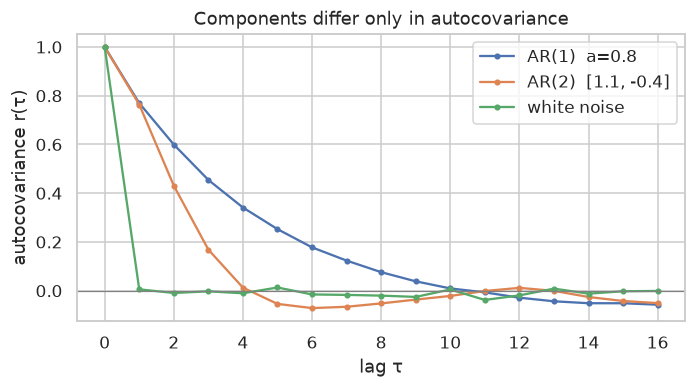

In [3]:
def autocov(rows, w=16):
    out = np.zeros(w + 1)
    for r in rows:
        for tau in range(w + 1):
            out[tau] += np.dot(r[: len(r) - tau], r[tau:]) / len(r)
    return out / len(rows)


fig, ax = plt.subplots(figsize=(6.4, 3.6))
for c, name in enumerate(NAMES):
    ax.plot(autocov(X[y == c]), "o-", ms=3, label=name)
ax.axhline(0, color="grey", lw=0.8)
ax.set(
    xlabel="lag τ", ylabel="autocovariance r(τ)", title="Components differ only in autocovariance"
)
ax.legend()
fig.tight_layout()
plt.show()

## Cluster it — only the Toeplitz head recovers the structure

The same 90 windows, `n_clusters=3`. betula's `gmm-toeplitz` is scored against the diagonal and full
GMM heads and scikit-learn's `GaussianMixture` — none of which can use the autocovariance.

Every table on this page is a **single draw at `seed=1`**, and this ladder is seed-sensitive: at
`d = 64` the three Toeplitz rungs span up to 0.18 ARI across seeds, so their *relative* order in a
one-seed table is luck. The seeded medians of record — seeds 0/1/2, with per-cell min/max — are in
[`bench/RESULTS.md`](../bench/RESULTS.md) § *Structured covariance* and
`bench/results_toeplitz_spread.csv`. What is seed-stable, and what this notebook is here to show, is
the gap between the Toeplitz rungs and everything else.

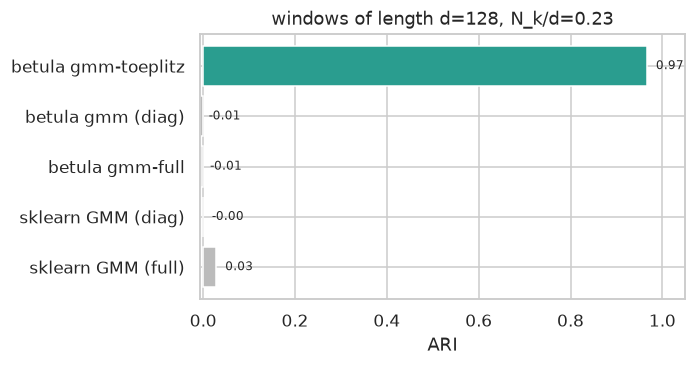

,ARI
method,
betula gmm-toeplitz,0.966
betula gmm (diag),-0.008
betula gmm-full,-0.005
sklearn GMM (diag),-0.001
sklearn GMM (full),0.028


In [4]:
kw = dict(feature="spherical", threshold=0.0, seed=1)
rows = [
    ("betula gmm-toeplitz", betula_cluster.fit_predict(X, 3, method="gmm-toeplitz", **kw)),
    (
        "betula gmm (diag)",
        betula_cluster.fit_predict(X, 3, method="gmm", feature="diagonal", threshold=0.0, seed=1),
    ),
    (
        "betula gmm-full",
        betula_cluster.fit_predict(X, 3, method="gmm-full", feature="full", threshold=0.0, seed=1),
    ),
    (
        "sklearn GMM (diag)",
        GaussianMixture(3, covariance_type="diag", n_init=8, random_state=0).fit_predict(X),
    ),
    (
        "sklearn GMM (full)",
        GaussianMixture(
            3, covariance_type="full", reg_covar=1e-3, n_init=8, random_state=0
        ).fit_predict(X),
    ),
]
tbl = pd.DataFrame(
    {"method": [r[0] for r in rows], "ARI": [round(ari(y, np.asarray(r[1])), 3) for r in rows]}
).set_index("method")

fig, ax = plt.subplots(figsize=(6.4, 3.4))
colors = ["#2a9d8f"] + ["#bbb"] * 4
ax.barh(range(len(tbl)), tbl["ARI"], color=colors)
ax.set(
    yticks=range(len(tbl)),
    xlabel="ARI",
    xlim=(min(0, tbl["ARI"].min()), 1.05),
    title=f"windows of length d={d}, N_k/d={30 / d:.2f}",
)
ax.set_yticklabels(tbl.index)
ax.invert_yaxis()
for i, v in enumerate(tbl["ARI"]):
    ax.text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=8)
fig.tight_layout()
plt.show()
tbl

## It gets *better* as the window grows

Longer windows push `N_k/d` down — fatal for full covariance, irrelevant for a diagonal model, and
**helpful** for `gmm-toeplitz`: more positions to pool the autocovariance from, so the AR estimate
sharpens to a perfect separation.

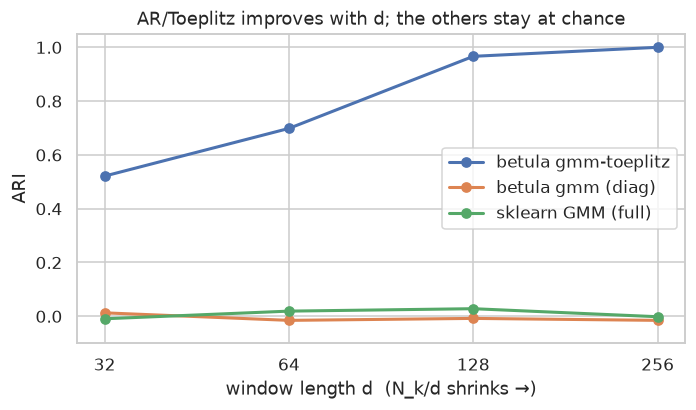

,betula gmm-toeplitz,betula gmm (diag),sklearn GMM (full)
d=32,0.521,0.013,-0.009
d=64,0.699,-0.015,0.019
d=128,0.966,-0.008,0.028
d=256,1.000,-0.015,-0.002


In [5]:
ds = [32, 64, 128, 256]
curve = {"betula gmm-toeplitz": [], "betula gmm (diag)": [], "sklearn GMM (full)": []}
for dd in ds:
    Xd, yd = make_mixture(dd, per=30, seed=1)
    curve["betula gmm-toeplitz"].append(
        ari(yd, np.asarray(betula_cluster.fit_predict(Xd, 3, method="gmm-toeplitz", **kw)))
    )
    curve["betula gmm (diag)"].append(
        ari(
            yd,
            np.asarray(
                betula_cluster.fit_predict(
                    Xd, 3, method="gmm", feature="diagonal", threshold=0.0, seed=1
                )
            ),
        )
    )
    curve["sklearn GMM (full)"].append(
        ari(
            yd,
            GaussianMixture(
                3, covariance_type="full", reg_covar=1e-3, n_init=8, random_state=0
            ).fit_predict(Xd),
        )
    )

fig, ax = plt.subplots(figsize=(6.4, 3.8))
for name, vals in curve.items():
    ax.plot(ds, vals, "o-", lw=2, label=name)
ax.set(
    xlabel="window length d  (N_k/d shrinks →)",
    ylabel="ARI",
    title="AR/Toeplitz improves with d; the others stay at chance",
    ylim=(-0.1, 1.05),
)
ax.set_xscale("log", base=2)
ax.set_xticks(ds)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.legend()
fig.tight_layout()
plt.show()

pd.DataFrame(curve, index=[f"d={dd}" for dd in ds]).round(3)

## When AR is not enough — `method="gmm-toeplitz-full"`

An AR(w) precision is **banded**: it can only express autocovariance up to lag `w`. Some signals carry
their structure *beyond* any low order — e.g. a **single echo** `x_t = e_t + 0.7·e_{t−K}` at a long lag
`K`. There `gmm-toeplitz` (capped at `w_max = 10`) is structurally blind, but the general
**`gmm-toeplitz-full`** head — a dense positive-definite Toeplitz covariance built from the *full*
(biased) autocovariance — captures it. It costs `O(d³)` per component instead of `O(d·w)`, so it is the
opt-in rung: reach for it only when the structure lives beyond a low AR order.

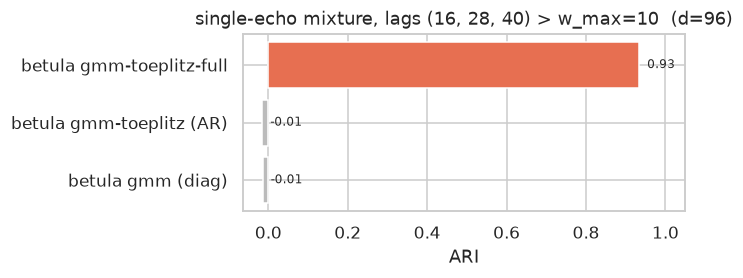

,ARI
method,
betula gmm-toeplitz-full,0.934
betula gmm-toeplitz (AR),-0.015
betula gmm (diag),-0.014


In [6]:
def echo_windows(n, d, lag, rng):
    """Single-echo MA `x_t = e_t + 0.7·e_{t−lag}`: autocovariance nonzero only at lags 0 and `lag`."""
    out = np.empty((n, d))
    for k in range(n):
        e = rng.normal(size=d + lag)
        win = e[lag:] + 0.7 * e[:d]
        out[k] = (win - win.mean()) / win.std()
    return out


ECHO = (16, 28, 40)  # echo lags, all beyond w_max=10


def echo_mixture(d, per, seed):
    rng = np.random.default_rng(seed)
    xs = [echo_windows(per, d, k, rng) for k in ECHO]
    y = np.concatenate([np.full(per, c) for c in range(len(ECHO))])
    return np.ascontiguousarray(np.vstack(xs), dtype=np.float64), y


de = 96
Xe, ye = echo_mixture(de, per=30, seed=1)
echo_rows = [
    (
        "betula gmm-toeplitz-full",
        betula_cluster.fit_predict(Xe, 3, method="gmm-toeplitz-full", **kw),
    ),
    ("betula gmm-toeplitz (AR)", betula_cluster.fit_predict(Xe, 3, method="gmm-toeplitz", **kw)),
    (
        "betula gmm (diag)",
        betula_cluster.fit_predict(Xe, 3, method="gmm", feature="diagonal", threshold=0.0, seed=1),
    ),
]
etbl = pd.DataFrame(
    {
        "method": [r[0] for r in echo_rows],
        "ARI": [round(ari(ye, np.asarray(r[1])), 3) for r in echo_rows],
    }
).set_index("method")

fig, ax = plt.subplots(figsize=(6.4, 2.6))
ax.barh(range(len(etbl)), etbl["ARI"], color=["#e76f51", "#bbb", "#bbb"])
ax.set(
    yticks=range(len(etbl)),
    xlabel="ARI",
    xlim=(min(0, etbl["ARI"].min()) - 0.05, 1.05),
    title=f"single-echo mixture, lags {ECHO} > w_max=10  (d={de})",
)
ax.set_yticklabels(etbl.index)
ax.invert_yaxis()
for i, v in enumerate(etbl["ARI"]):
    ax.text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=8)
fig.tight_layout()
plt.show()
etbl

## The third rung — `method="gmm-toeplitz-gs"` (likelihood-optimal precision)

Between the banded AR head and the dense-covariance one sits **`gmm-toeplitz-gs`**: the paper's full
**Gohberg-Semencul MLE**. It fits a positive-definite Toeplitz *precision* by maximizing the exact AR
log-likelihood — a Yule-Walker (Levinson) warm start refined by coordinate ascent over the reflection
coefficients (PD guaranteed by `|k| < 1`, deterministic). On a **mid-lag echo** (lags `11–15`, *beyond*
the banded head's `w_max = 10` but within the GS order cap) it recovers the structure the AR head
misses, at a **precision** E-step that is cheaper than the dense `O(d³)` covariance of `-full` at large
`d`. The covariance-route `-full` head still wins on *arbitrarily* long lags (the order cap is the
trade-off) — the three routes are complementary.

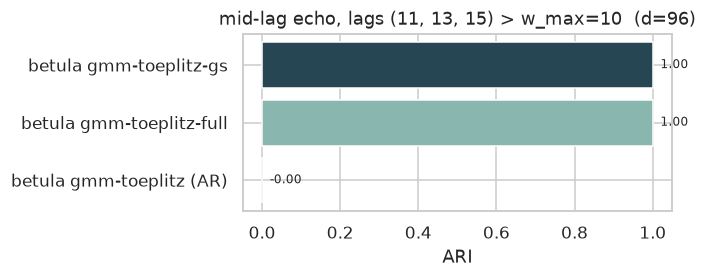

,ARI
method,
betula gmm-toeplitz-gs,1.0
betula gmm-toeplitz-full,1.0
betula gmm-toeplitz (AR),-0.0


In [7]:
GS_ECHO = (11, 13, 15)  # mid-lag echoes: beyond w_max=10, within the GS order cap


def gs_echo_mixture(d, per, seed):
    rng = np.random.default_rng(seed)
    xs = [echo_windows(per, d, k, rng) for k in GS_ECHO]
    y = np.concatenate([np.full(per, c) for c in range(len(GS_ECHO))])
    return np.ascontiguousarray(np.vstack(xs), dtype=np.float64), y


dg = 96
Xg, yg = gs_echo_mixture(dg, per=30, seed=1)
gs_rows = [
    ("betula gmm-toeplitz-gs", betula_cluster.fit_predict(Xg, 3, method="gmm-toeplitz-gs", **kw)),
    (
        "betula gmm-toeplitz-full",
        betula_cluster.fit_predict(Xg, 3, method="gmm-toeplitz-full", **kw),
    ),
    ("betula gmm-toeplitz (AR)", betula_cluster.fit_predict(Xg, 3, method="gmm-toeplitz", **kw)),
]
gtbl = pd.DataFrame(
    {
        "method": [r[0] for r in gs_rows],
        "ARI": [round(ari(yg, np.asarray(r[1])), 3) for r in gs_rows],
    }
).set_index("method")

fig, ax = plt.subplots(figsize=(6.4, 2.6))
ax.barh(range(len(gtbl)), gtbl["ARI"], color=["#264653", "#8ab6b0", "#bbb"])
ax.set(
    yticks=range(len(gtbl)),
    xlabel="ARI",
    xlim=(min(0, gtbl["ARI"].min()) - 0.05, 1.05),
    title=f"mid-lag echo, lags {GS_ECHO} > w_max=10  (d={dg})",
)
ax.set_yticklabels(gtbl.index)
ax.invert_yaxis()
for i, v in enumerate(gtbl["ARI"]):
    ax.text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=8)
fig.tight_layout()
plt.show()
gtbl

**Takeaway.** For **ordered, stationary** signals — time-series windows, trajectories, sensor
waveforms — the neighbour correlation is the signal, and the Toeplitz heads are the ones that model
it, in a **three-rung ladder**. **`method="gmm-toeplitz"`** fits an AR(w) / Toeplitz precision
(positive-definite by construction, `O(w)` parameters, order by BIC) that stays well-posed exactly
where diagonal is blind and full covariance is singular; **`method="gmm-toeplitz-full"`** drops the AR
order cap for a general positive-definite Toeplitz *covariance* (`O(d³)`) when the structure lives
beyond a low order (the long-lag echo); **`method="gmm-toeplitz-gs"`** fits a likelihood-optimal
Gohberg-Semencul *precision* (mid-lag structure, cheaper E-step than full at large `d`). Use
`feature="spherical"` or `"diagonal"`; all run over the CF microclusters like every other head, so they
inherit betula's scale and bounded memory. **For ordered coordinates only** — on generic embeddings a
coordinate permutation would destroy the Toeplitz structure, so reach for `gmm` / `gmm-full` there. See
the [Usage guide](../docs/USAGE.md) and
[`docs/MATH.md`](../docs/MATH.md#toeplitz--ar-covariance-for-stationary-signals).